# Tokenización y Representaciones Vectoriales en LLMs

## ¿Qué es la tokenización?

Antes de que un modelo de lenguaje como GPT o BERT pueda procesar texto, necesita convertir las palabras (o partes de palabras) en números. Este proceso se llama **tokenización**.

Un **token** es la unidad básica de texto que el modelo "ve". Puede ser:
- Una palabra completa: `"perro"` → token
- Un subpalabra: `"tokenización"` → `["token", "ización"]`
- Un carácter individual

## ¿Qué es un embedding (representación vectorial)?

Una vez tokenizado el texto, cada token se mapea a un **vector de números reales** en un espacio de alta dimensión. Este vector es el *embedding* del token.

**¿Por qué vectores?** Porque nos permiten representar el *significado semántico* de las palabras de forma matemática. Palabras con significados similares quedan **cerca** en este espacio vectorial.

```
"rey"   → [0.23, -0.81, 0.45, ..., 0.12]  (300 números)
"reina" → [0.21, -0.79, 0.48, ..., 0.15]  (300 números, ¡muy similar!)
"mesa"  → [-0.54, 0.33, -0.12, ..., 0.87] (300 números, muy diferente)
```

En este notebook usaremos **Word2Vec** (Google News), un modelo clásico entrenado sobre millones de artículos de noticias, para explorar estas representaciones.

## Paso 1 — Instalar dependencias

`gensim` es una librería de Python especializada en modelos de lenguaje y representaciones vectoriales. La usaremos para cargar modelos Word2Vec pre-entrenados sin necesidad de entrenar desde cero.

In [ ]:
!pip install gensim

## Paso 2 — Cargar el modelo Word2Vec

Cargamos el modelo `word2vec-google-news-300`, entrenado por Google sobre ~100 mil millones de palabras de artículos de noticias.

- Contiene ~3 millones de palabras/frases en su vocabulario
- Cada token está representado por un vector de **300 dimensiones**

> **Nota:** La primera vez esto descarga ~1.6 GB. Después queda en caché local.

In [ ]:
import gensim.downloader as api

# Load pre-trained Word2Vec model
model = api.load("word2vec-google-news-300")

[==================================================] 100.0% 1662.8/1662.8MB downloaded


## Paso 3 — ¿Cuántas dimensiones tiene un embedding?

Verifiquemos la dimensión del vector de la palabra `"apple"`. Cada token en este modelo está representado como un punto en un espacio de **300 dimensiones**.

Aunque 300 dimensiones es imposible de visualizar directamente, podemos usar técnicas de reducción dimensional como **PCA** (Análisis de Componentes Principales) o **t-SNE** para proyectarlos en 2D o 3D y así visualizar las relaciones semánticas entre palabras.

In [ ]:
len(model['apple'])

300

## Paso 4 — Aritmética vectorial: la magia de los embeddings

Una de las propiedades más fascinantes de los embeddings es que **las relaciones semánticas se preservan como operaciones vectoriales**.

El experimento clásico es:

$$\vec{king} - \vec{man} + \vec{woman} \approx \vec{queen}$$

¿Qué significa esto? El vector que va de `"man"` a `"king"` (la *dirección de realeza*) es aproximadamente el mismo que el que va de `"woman"` a `"queen"`. El modelo aprendió este concepto implícitamente al leer millones de textos — **nadie le enseñó explícitamente qué es un rey o una reina**.

### Visualización con PCA 3D

Como no podemos graficar 300 dimensiones, usamos **PCA** para reducir a 3D, buscando las tres direcciones que capturan la mayor varianza. Las líneas rojas y azules muestran la similitud coseno entre el vector resultado y `king`/`queen`.

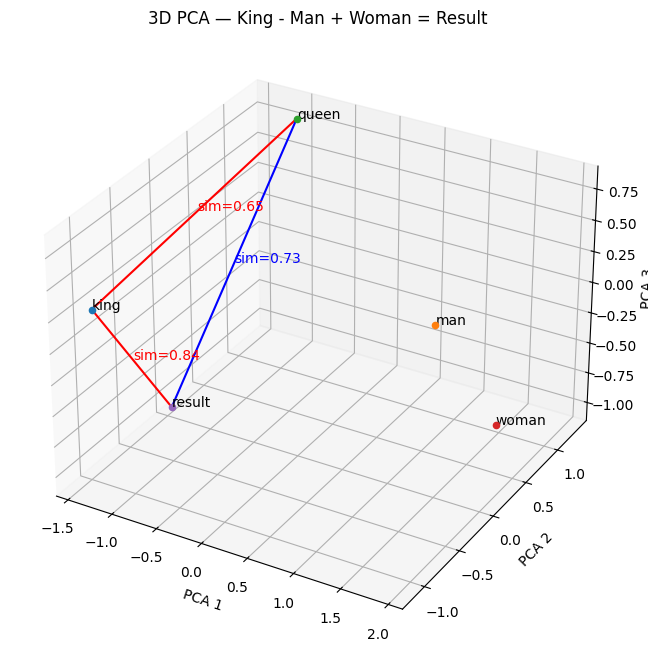

In [ ]:
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np


v_king = model['king']
v_man = model['man']
v_woman = model['woman']
v_queen = model['queen']
v_result = v_king - v_man + v_woman


words_to_plot = ['king', 'man', 'queen', 'woman', 'result']
vectors_to_plot = [v_king, v_man, v_queen, v_woman, v_result]

pca = PCA(n_components=3)
reduced = pca.fit_transform(vectors_to_plot)
coords = {word: reduced[i] for i, word in enumerate(words_to_plot)}

def cos(a, b):
    return cosine_similarity([a], [b])[0, 0]

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

for word, vec in coords.items():
    ax.scatter(vec[0], vec[1], vec[2])
    ax.text(vec[0], vec[1], vec[2], word)

result = coords['result']
king = coords['king']
queen = coords['queen']

# Result ↔ King
ax.plot([result[0], king[0]], [result[1], king[1]], [result[2], king[2]], color='red')
mid_rk = (result + king) / 2.0
ax.text(mid_rk[0], mid_rk[1], mid_rk[2],
        f"sim={cos(v_result, v_king):.2f}", color='red')

# King ↔ Queen
ax.plot([king[0], queen[0]], [king[1], queen[1]], [king[2], queen[2]], color='red')
mid_kq = (king + queen) / 2.0
ax.text(mid_kq[0], mid_kq[1], mid_kq[2],
        f"sim={cos(v_king, v_queen):.2f}", color='red')

# Result ↔ Queen
ax.plot([result[0], queen[0]], [result[1], queen[1]], [result[2], queen[2]], color='blue')
mid_rq = (result + queen) / 2.0
ax.text(mid_rq[0], mid_rq[1], mid_rq[2],
        f"sim={cos(v_result, v_queen):.2f}", color='blue')

ax.set_title("3D PCA — King - Man + Woman = Result")
ax.set_xlabel("PCA 1"); ax.set_ylabel("PCA 2"); ax.set_zlabel("PCA 3")
plt.show()

## Paso 5 — ¿A qué palabras se parece el resultado?

Ahora buscamos los 10 tokens más similares al vector resultado de `king - man + woman` usando **similitud coseno**.

La similitud coseno mide el ángulo entre dos vectores en el espacio de embeddings:
- `sim = 1.0` → misma dirección (palabras idénticas o sinónimos perfectos)
- `sim ≈ 0.7` → fuertemente relacionadas
- `sim ≈ 0.0` → sin relación semántica

Si los embeddings capturaron bien la semántica, deberíamos ver `"queen"` entre los primeros resultados — y de hecho aparece en el segundo lugar.

In [ ]:
similar_words = model.most_similar(positive=[v_result], topn=10)

print("Top 10 palabras mas similares a la operación 'king - man + woman':")
for word, similarity in similar_words:
    print(f"{word}: {similarity:.4f}")

Top 10 palabras mas similares a la operación 'king - man + woman':
king: 0.8449
queen: 0.7301
monarch: 0.6455
princess: 0.6156
crown_prince: 0.5819
prince: 0.5777
kings: 0.5614
sultan: 0.5377
Queen_Consort: 0.5344
queens: 0.5290


### Vecinos más cercanos de `"queen"`

Para comparar, veamos directamente los 10 tokens más similares a `"queen"`. Esto nos dice qué conceptos el modelo asocia con ser reina. Observa que `king` aparece como vecino de `queen` y viceversa — los embeddings capturaron la relación bidireccional entre estos conceptos.

In [ ]:
similar_words = model.most_similar(positive=[v_queen], topn=10)

print("Top 10 palabras mas similares a la operación 'queen':")
for word, similarity in similar_words:
    print(f"{word}: {similarity:.4f}")

Top 10 palabras mas similares a la operación 'queen':
queen: 1.0000
queens: 0.7399
princess: 0.7071
king: 0.6511
monarch: 0.6384
very_pampered_McElhatton: 0.6357
Queen: 0.6163
NYC_anglophiles_aflutter: 0.6061
Queen_Consort: 0.5924
princesses: 0.5908


### Vecinos más cercanos de `"king"`

Finalmente, los 10 tokens más similares a `"king"`. Compara los vecinos de `king` vs. los de `queen`: ¿son simétricos? ¿Hay sesgos del corpus de entrenamiento que puedas identificar?

In [ ]:
similar_words = model.most_similar(positive=[v_king], topn=10)

print("Top 10 palabras mas similares a la operación 'king':")
for word, similarity in similar_words:
    print(f"{word}: {similarity:.4f}")

Top 10 palabras mas similares a la operación 'king':
king: 1.0000
kings: 0.7138
queen: 0.6511
monarch: 0.6413
crown_prince: 0.6204
prince: 0.6160
sultan: 0.5865
ruler: 0.5798
princes: 0.5647
Prince_Paras: 0.5433


---
## Reto: Explora tu propio espacio semántico

Ahora es tu turno. Usando el modelo Word2Vec que ya cargamos, realiza las siguientes exploraciones:

### Parte 1 — Tu animal favorito
1. Elige tu animal favorito en inglés (e.g., `"dolphin"`, `"tiger"`, `"eagle"`)
2. Obtén su vector: `v_animal = model["nombre_del_animal"]`
3. Busca los 10 tokens más similares
4. ¿Los resultados tienen sentido semántico? ¿Encuentras tokens sorprendentes?

### Parte 2 — Operaciones vectoriales
Diseña operaciones análogas a `king - man + woman` con tu animal:
- `"dog" - "domestic" + "wild"` → ¿a qué llega?
- `"eagle" - "fly" + "swim"` → ¿qué predice el modelo?
- Inventa tu propia operación semántica y explica qué esperabas y qué obtuviste

### Parte 3 — Visualización
Toma tu animal, sus vecinos más cercanos y alguna operación vectorial, y grafícalos en 3D con PCA igual que hicimos arriba. ¿Forman clusters semánticos con sentido?

> **Tip:** Si una palabra no está en el vocabulario, el modelo lanzará un `KeyError`. Verifica con `"palabra" in model.key_to_index` antes de usarla.

In [ ]:
# === RETO: completa y experimenta con este código ===

# ----- Parte 1: Tu animal favorito -----
mi_animal = "dolphin"  # <-- cambia esto por tu animal favorito (en inglés)

if mi_animal in model.key_to_index:
    v_animal = model[mi_animal]
    print(f"Vector dimension of '{mi_animal}': {len(v_animal)}")
    print(f"\nTop 10 most similar words to '{mi_animal}':")
    for word, sim in model.most_similar(positive=[v_animal], topn=10):
        print(f"  {word}: {sim:.4f}")
else:
    print(f"'{mi_animal}' is not in the vocabulary. Try another word.")

# ----- Parte 2: Operación vectorial -----
# Descomenta, modifica y ejecuta:
# v_op = model["dog"] - model["domestic"] + model["wild"]
# print("\ndog - domestic + wild ->")
# for word, sim in model.most_similar(positive=[v_op], topn=5):
#     print(f"  {word}: {sim:.4f}")

# ----- Parte 3: Visualización 3D -----
# Agrega o cambia las palabras que quieras explorar:
# palabras = [mi_animal, "fish", "ocean", "sea", "swim", "mammal", "whale"]
# palabras = [w for w in palabras if w in model.key_to_index]
# vectores = [model[w] for w in palabras]
#
# from sklearn.decomposition import PCA
# import matplotlib.pyplot as plt
# pca = PCA(n_components=3)
# reduced = pca.fit_transform(vectores)
#
# fig = plt.figure(figsize=(10, 8))
# ax = fig.add_subplot(111, projection='3d')
# for i, word in enumerate(palabras):
#     ax.scatter(*reduced[i])
#     ax.text(*reduced[i], word)
# ax.set_title(f"3D PCA — Semantic neighbors of '{mi_animal}'")
# ax.set_xlabel('PCA 1'); ax.set_ylabel('PCA 2'); ax.set_zlabel('PCA 3')
# plt.show()
